# Prise en mains des fichiers GLORYS12 

## Chargement des fichiers .nc 

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

pathdir = "/mnt/data/jmv/Unilasalle/datacopernicus/"
ds = xr.open_dataset(f"{pathdir}glorys12_1day_2020-03-28.nc")

ds

<xarray.Dataset> Size: 6MB
Dimensions:    (time: 1, depth: 50, latitude: 121, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 8B 2020-03-28
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 484B -40.0 -39.92 -39.83 ... -30.08 -30.0
  * longitude  (longitude) float32 484B -40.0 -39.92 -39.83 ... -30.08 -30.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 6MB ...
Attributes:
    Conventions:  CF-1.4
    institution:  MERCATOR OCEAN
    references:   http://www.mercator-ocean.fr
    source:       MERCATOR GLORYS12V1
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...
    comment:      CMEMS product
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation

## Dimensions coordonnées et variables 

In [12]:
# Coordonées du nc
print("Coordonnées :", list(ds.coords))
print("Dimensions :", ds.dims)
# Variables présentes
print("Variables :", list(ds.data_vars))


Coordonnées : ['depth', 'latitude', 'longitude', 'time']
Dimensions : FrozenMappingWarningOnValuesAccess({'time': 1, 'depth': 50, 'latitude': 121, 'longitude': 121})
Variables : ['thetao']


## Description des grilles et unités 

In [13]:
lon_min, lon_max = float(ds['longitude'].min()), float(ds['longitude'].max())
lat_min, lat_max = float(ds['latitude'].min()), float(ds['latitude'].max())
depth_min, depth_max = float(ds['depth'].min()), float(ds['depth'].max())
depth_unit = ds['depth'].attrs.get('units', 'non spécifiée')

print(f"Grille longitudinale : {lon_min}° à {lon_max}°")
print(f"Grille latitudinale  : {lat_min}° à {lat_max}°")
print(f"Profondeur            : {depth_min} à {depth_max} {depth_unit}")

Grille longitudinale : -40.0° à -30.0°
Grille latitudinale  : -40.0° à -30.0°
Profondeur            : 0.49402499198913574 à 5727.9169921875 m


## Exemple d'inspection d'une variable

In [14]:
def descript_variable(var):
    print("Nom long :", var.attrs.get('long_name', ''))
    print("Nom standard :", var.attrs.get('standard_name', ''))
    print("Unité :", var.attrs.get('units', ''))
    print("Dimensions :", var.dims)
    print("Shape :", var.shape)
    return 

In [15]:
var = "thetao"

In [16]:
descript_variable(ds[var]) 

Nom long : Temperature
Nom standard : sea_water_potential_temperature
Unité : degrees_C
Dimensions : ('time', 'depth', 'latitude', 'longitude')
Shape : (1, 50, 121, 121)


## Visualisation 2D 

In [6]:
var = "thetao"# choix de la variable ['so', 'thetao', 'uo', 'vo']

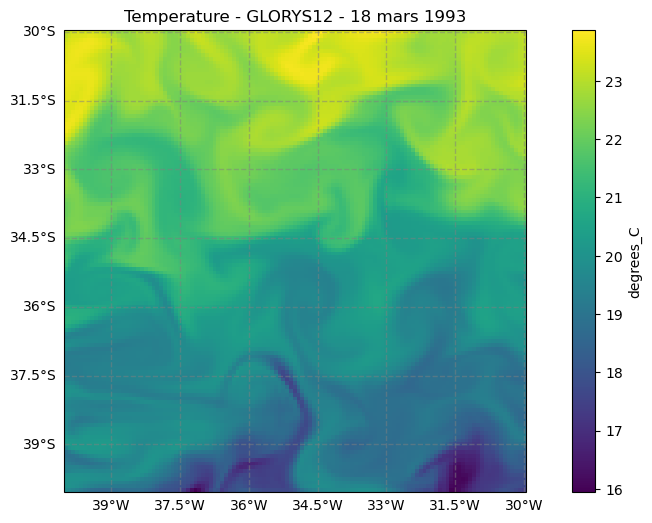

In [7]:
var_surface = ds[var].isel(depth=0, time=0)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

var_surface.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    add_colorbar=True,
    cbar_kwargs={'label': ds[var].attrs.get('units', '')},
    add_labels=False
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Titre
ax.set_title(f"{var_surface.attrs.get('long_name', '')} - GLORYS12 - 18 mars 1993")

plt.show()


## Profil vertical

In [19]:
var = "thetao"# choix de la variable ['so', 'thetao', 'uo', 'vo']

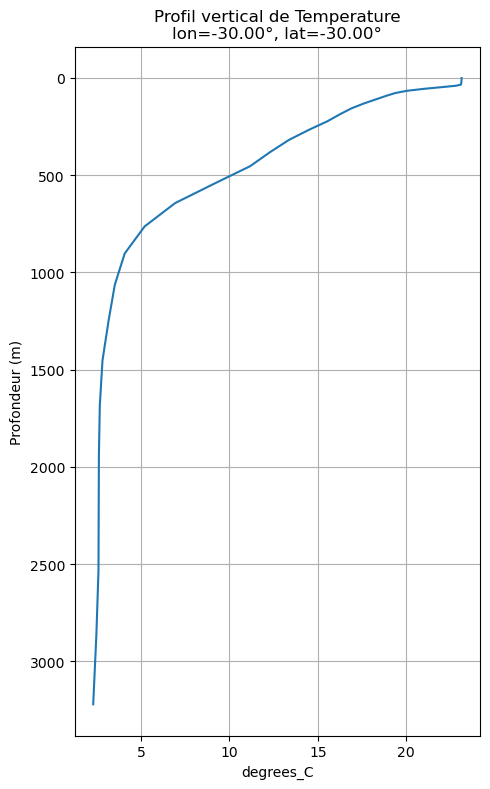

In [20]:
# à adapter
lon_target = -30.0  # exemple : 30°O
lat_target = 45.0   # exemple : 45°N

# Si indice non grillé, on recherhce le plus proche 
lon_idx = abs(ds['longitude'] - lon_target).argmin().item()
lat_idx = abs(ds['latitude'] - lat_target).argmin().item()

# Choix de la variable ['so', 'thetao', 'uo', 'vo', 'zos']
var_profil = ds[var]
profil = var_profil.isel(
    time=0,
    longitude=lon_idx,
    latitude=lat_idx
)

plt.figure(figsize=(5, 8))
plt.plot(profil, ds['depth'])
plt.gca().invert_yaxis()
plt.xlabel(ds[var].attrs.get('units', ''))
plt.ylabel("Profondeur (m)")
plt.title(f"Profil vertical de {var_profil.attrs.get('long_name', '')}\nlon={ds['longitude'][lon_idx].item():.2f}°, lat={ds['latitude'][lat_idx].item():.2f}°")
plt.grid()
plt.tight_layout()
plt.show()

## Autre visualisation : Coupe dans la colonne d'eau 

In [21]:
var = "thetao"# choix de la variable ['so', 'thetao', 'uo', 'vo']

/tmp/ipykernel_1425722/3430180274.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  idx_lat = ds.dims['latitude'] // 2


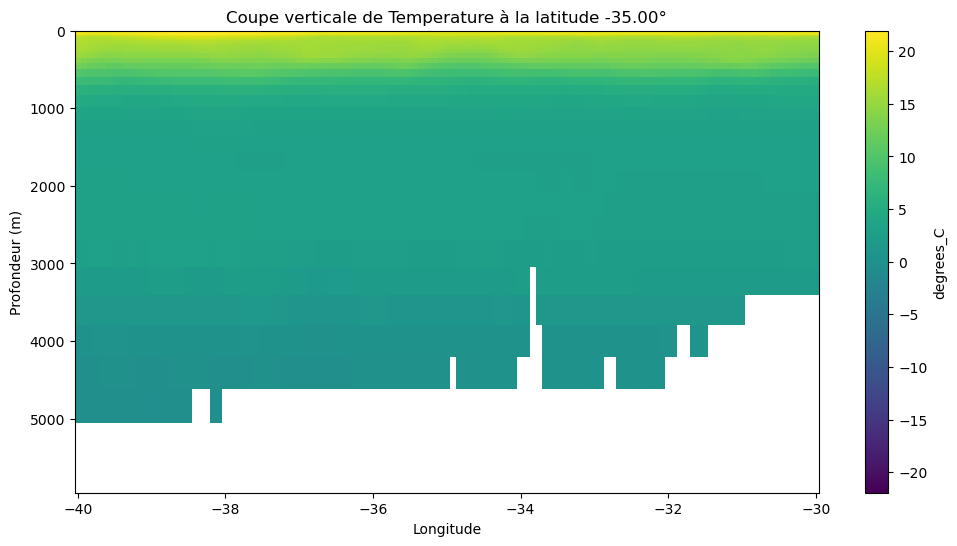

In [22]:
# On coupe à la moitié de la latitude
idx_lat = ds.dims['latitude'] // 2
lat_val = ds['latitude'].isel(latitude=idx_lat).values

var_section = ds[var].isel(latitude=idx_lat, time=0)

var_section.plot(
    x='longitude',
    y='depth',
    yincrease=False,  # profondeur vers le bas
    cmap='viridis',
    figsize=(12, 6),
    cbar_kwargs={'label': ds[var].attrs.get('units', '')}
)
plt.title(f"Coupe verticale de {var_section.attrs.get('long_name', '')} à la latitude {lat_val:.2f}°")
plt.xlabel("Longitude")
plt.ylabel("Profondeur (m)")
plt.show()